### Super Store Sale Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')
store_sale = pd.read_csv('superstore_eda.csv')
store_sale_copy = store_sale.copy() 

In [2]:
# Removing Duplicates:
print("Duplicated Before: ", store_sale.duplicated().sum())
store_sale_copy = store_sale_copy.drop_duplicates()
print("Duplicated After : ", store_sale_copy.duplicated().sum())

Duplicated Before:  17
Duplicated After :  0


In [3]:
store_sale_copy['Ship Date'].unique() # checked different values in both Ship and Order Date 
store_sale_copy['Order Date'].unique()

array(['08/11/16', '12/06/16', '11/10/15', ..., '28/12/19', '12/04/15',
       '21/01/14'], shape=(1240,), dtype=object)

`Converted the date columns in the appropriate data type that is data_time`

In [4]:
store_sale_copy['Ship Date']=pd.to_datetime(store_sale_copy['Ship Date'], format = 'mixed', dayfirst = True)
store_sale_copy['Order Date']=pd.to_datetime(store_sale_copy['Order Date'],format = 'mixed', dayfirst = True)

`Since intially there is mismatch between Order ID and Order Date Year. Hence, extracted the Year from Order ID and replace with it Order Date year`

In [5]:
store_sale_copy['Order Year'] = store_sale_copy['Order ID'].apply(
    lambda x : int(x.split('-')[1])
)

In [6]:
store_sale_copy['Order Date Year'] = store_sale_copy['Order Date'].dt.year 

inconsistent = store_sale_copy[store_sale_copy['Order Year'] != store_sale_copy['Order Date Year']] # Checked whether the Year from Order ID and Order Date are equal now or not after extraction
inconsistent.index

Index([  62,   63,   64,   65,  943,  944,  945, 1152, 1153, 2752, 2753, 2754,
       2755, 2756, 2821, 3537, 3538, 3539, 3540, 4448, 4449, 4450, 4612, 4613,
       5289, 5290, 5291, 5372, 5373, 5374, 5738, 6341, 6387, 6388, 8586, 8587,
       8595, 8596, 9942, 9943],
      dtype='int64')

`Changes done for Order Date 'Year' in the inconsistent indexes after the extraction Year from Order ID`

In [7]:
store_sale_copy.loc[inconsistent.index, 'Order Date'] = store_sale_copy.loc[inconsistent.index].apply(
    lambda x : x['Order Date'].replace(year=x['Order Year']), axis = 1 
)

impacted_rows = inconsistent.shape[0]
impacted_order_ids = inconsistent['Order ID'].nunique()

print(f"Rows impacted by date correction: {impacted_rows}")
print(f"Distinct Order IDs impacted: {impacted_order_ids}")

Rows impacted by date correction: 40
Distinct Order IDs impacted: 16


In [8]:
store_sale_copy['days_to_ship'] =  (store_sale_copy['Ship Date'] - store_sale_copy['Order Date']).dt.days # Created new column days_to_ship by difference in Ship Date and Order Date

In [9]:
store_sale_copy[store_sale_copy['days_to_ship']< 0] [['Order Date','Ship Date','days_to_ship']] # Negative difference in days which is not possible that is Shipped earlier and Ordered earlier

,Order Date,Ship Date,days_to_ship
1152,2017-12-31,2017-01-06,-359
1153,2017-12-31,2017-01-06,-359
2821,2017-12-31,2017-01-05,-360
4612,2017-12-31,2017-01-06,-359
4613,2017-12-31,2017-01-06,-359
5738,2017-12-31,2017-01-06,-359
6341,2017-12-31,2017-01-02,-363


In [10]:
store_sale_copy = store_sale_copy[store_sale_copy['days_to_ship'] >= 0] # Removed the Negative dates from our data only kept where days_to_ship is 0 & greater than zero

In [11]:
store_sale_copy.loc[62: , ['Order ID','Order Date','Ship Date']]
store_sale_copy

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit,Order Year,Order Date Year,days_to_ship
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,2016,2016,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,2016,2016,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,2016,2016,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,2015,2015,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,2015,2015,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4.0,0.00,13.3200,2017,2017,5
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.1600,2.0,0.00,72.9480,2017,2017,5
9998,20,CA-2014-143336,2014-08-27,2014-09-01,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,...,Technology,Phones,Cisco SPA 501G IP Phone,213.4800,3.0,0.20,16.0110,2014,2014,5
10000,8852,CA-2015-140718,2015-07-02,2015-07-04,First Class,FA-14230,Frank Atkinson,Corporate,United States,Raleigh,...,Office Supplies,Paper,Things To Do Today Pad,-9.3920,2.0,0.20,3.2872,2015,2015,2


In [12]:
store_sale_copy.isna().sum().sort_values(ascending = False)

Ship Mode          98
Quantity           18
Row ID              0
Product ID          0
Order Date Year     0
Order Year          0
Profit              0
Discount            0
Sales Price         0
Product Name        0
Sub-Category        0
Category            0
Region              0
Order ID            0
Postal Code         0
State               0
City                0
Country             0
Segment             0
Customer Name       0
Customer ID         0
Ship Date           0
Order Date          0
days_to_ship        0
dtype: int64

`Updating the Ship Mode column on the basis of days_to_ship`

In [13]:
store_sale_copy['Ship Mode']  = store_sale_copy.apply(
    lambda x : 'Same Day'if x['days_to_ship'] == 0
    else ('Standard Class' if x['days_to_ship'] == 7
    else x['Ship Mode']), axis = 1
)

In [14]:
store_sale_copy['Ship Mode'].value_counts() # Checked Counts of different Ship modes

Ship Mode
Standard Class    5962
Second Class      1946
First Class       1539
Same Day           543
Name: count, dtype: int64

In [15]:
store_sale_copy['Quantity'].isna().sum() # 18 null values in Quantity Column

np.int64(18)

`On the basis of Cofficient of variation imputed the Null Values in the Quantity Column`

In [16]:
Coff_Var = (store_sale_copy['Quantity'].std()) / (store_sale_copy['Quantity'].mean())
Coff_Var # 0.5874856450128176 "If CV > 50%, impute with median if CV < 50%, impute with mean"

np.float64(0.5874856450128176)

In [17]:
store_sale_copy['Quantity'].unique()

array([ 2.,  3.,  5.,  7.,  4.,  6.,  9., nan,  1.,  8., 14., 11., 13.,
       10., 12.])

In [18]:
median_qan = store_sale_copy['Quantity'].median()
print((median_qan))

3.0


In [19]:
store_sale_copy['Quantity'] = store_sale_copy['Quantity'].fillna('median_qan')

In [20]:
store_sale_copy['Quantity'].isna().sum()

np.int64(0)

In [21]:
Original_number_of_rows = store_sale.shape[0]
copy_number_row = store_sale_copy.shape[0]
Original_orderIDs =  store_sale['Order ID'].nunique()
Copy_orderIDs =  store_sale_copy['Order ID'].nunique()
print(f'Rows Before {Original_number_of_rows}, After {copy_number_row}')
print(f'OrderID Before {Original_orderIDs}, After {Copy_orderIDs}')


Rows Before 10014, After 9990
OrderID Before 5009, After 5004


`Dropped the Customer name to ensure the privacy`

In [22]:
store_sale_copy.drop('Customer Name', axis = 1, inplace = True, errors = "corece" )

In [23]:
store_sale_copy["Masked name"] = store_sale_copy['Customer ID'].apply(lambda x : x.split('-')[0]) # Extract Customer Short Name from Customer ID    

In [24]:
store_sale_copy['Postal Code'] = store_sale_copy['Postal Code'].astype('str').str.zfill(5) # Used zfill to ensure all postcodes are formatted as 5-digits string

In [25]:
store_sale_copy['Quantity'] = pd.to_numeric(store_sale_copy['Quantity'], errors = 'coerce')

`Replaced the abbreviations with Full State names`

In [26]:
store_sale_copy['State'] = store_sale_copy['State'].str.strip('\\') # removed leading/trailing backslash 
store_sale_copy['State'] = store_sale_copy['State'].str.strip(' ') # removed leading/trailing spaces 

abbr_to_us_state = {
    'CA': 'California', 
    'NJ': 'New Jersey',
    'NY': 'New York',
    'TX': 'Texas',
    'WA': 'Washington'
}

In [27]:
store_sale_copy['State'] = store_sale_copy['State'].replace(abbr_to_us_state)

In [28]:
store_sale_copy["State"].value_counts() # No abbreviations left

State
California              2000
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 493
Ohio                     468
Florida                  381
Michigan                 255
North Carolina           250
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   124
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Oklahoma                  66
Missouri                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Mississippi               53
Utah                      53
Louisiana                 42
South Carolina            42
Nebraska

`Feature engineering to analyze the data more accurately`

In [29]:
store_sale_copy['Original Price'] = store_sale_copy['Sales Price']/(1-store_sale_copy['Discount']) # Original price per item
store_sale_copy['Total Sales'] = store_sale_copy['Sales Price'] * store_sale_copy['Quantity'] # Total sale or Total revenue per item
store_sale_copy['Total Profit'] = store_sale_copy['Profit'] * store_sale_copy['Quantity'] # Total profit for total quantity 
store_sale_copy['Discount Price'] = (store_sale_copy['Sales Price'] * store_sale_copy['Discount']) # Discounted price per item 
store_sale_copy['Total Discount'] = store_sale_copy['Discount Price'] * store_sale_copy['Quantity'] # Discounted price for total quanity purchased

In [30]:
store_sale_copy['Shipping Urgency'] = store_sale_copy.apply( #Categorize shipping speed using days_to_ship
    lambda x : 'Immediate' if x['days_to_ship'] == 0 
    else ('Urgent' if x['days_to_ship'] in [1,2,3]
    else 'Standard' ), axis = 1
) 

`Checked how frequently customers place orders`

In [31]:
store_sale_copy = store_sale_copy.sort_values(by=['Masked name', 'Order Date']) # Sort the data by first customer name alphabetically then their order dates in ascending order in a group
store_sale_copy['Days Since Last Order'] = store_sale_copy.groupby('Masked name')['Order Date'].diff().dt.days # Group by Masked name then calculate diffrence in order dates by uisng .diff()

In [32]:
store_sale_copy

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Order Date Year,days_to_ship,Masked name,Original Price,Total Sales,Total Profit,Discount Price,Total Discount,Shipping Urgency,Days Since Last Order
2229,2230,CA-2014-128055,2014-03-31,2014-04-05,Standard Class,AA-10315,Consumer,United States,San Francisco,California,...,2014,5,AA,841.96,1347.136,505.1760,134.7136,269.4272,Standard,NaN
2230,2231,CA-2014-128055,2014-03-31,2014-04-05,Standard Class,AA-10315,Consumer,United States,San Francisco,California,...,2014,5,AA,52.98,105.960,29.6688,0.0000,0.0000,Standard,0.0
1172,1173,CA-2014-158064,2014-04-21,2014-04-25,Standard Class,AA-10375,Consumer,United States,Los Angeles,California,...,2014,4,AA,20.65,82.600,27.8775,3.3040,16.5200,Standard,21.0
1459,1460,CA-2014-155271,2014-05-04,2014-05-04,Same Day,AA-10480,Consumer,United States,Middletown,Connecticut,...,2014,0,AA,27.46,54.920,19.7712,0.0000,0.0000,Immediate,13.0
4020,4021,CA-2014-154963,2014-06-22,2014-06-27,Standard Class,AA-10645,Consumer,United States,Chester,Pennsylvania,...,2014,5,AA,242.94,510.174,-14.5764,51.0174,153.0522,Standard,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5898,5899,CA-2016-167682,2016-04-03,2016-04-09,Standard Class,ZD-21925,Consumer,United States,Richmond,Indiana,...,2016,6,ZD,259.96,1039.840,499.1232,0.0000,0.0000,Standard,0.0
3040,3041,US-2016-147991,2016-05-05,2016-05-09,Standard Class,ZD-21925,Consumer,United States,Chattanooga,Tennessee,...,2016,4,ZD,20.90,83.600,16.7200,3.3440,16.7200,Standard,32.0
3814,3815,CA-2016-152471,2016-07-08,2016-07-08,Same Day,ZD-21925,Consumer,United States,Jacksonville,Florida,...,2016,0,ZD,1029.95,4119.800,257.4875,164.7920,823.9600,Immediate,64.0
3815,3816,CA-2016-152471,2016-07-08,2016-07-08,Same Day,ZD-21925,Consumer,United States,Jacksonville,Florida,...,2016,0,ZD,19.98,31.968,9.9900,3.1968,6.3936,Immediate,0.0


`Analze Total Sales,Quantity & Discount for every customer`

In [33]:
customer_new_data_set = store_sale_copy.groupby('Customer ID')[['Total Sales','Quantity','Total Discount']].sum().reset_index() 
customer_new_data_set.columns = ['Customer ID','Total Sales per Customer','Quantity per Customer','Total Discount per Customer'] # Renaming columns to avoid overlapping the columns
store_sale_copy = pd.merge(store_sale_copy, customer_new_data_set , how = 'left', on = 'Customer ID') 

# Foreign-to-Primary Key Join: Customer ID is a unique Primary Key in customer_new_data_set (due to groupby)
# and a Foreign Key in store_sale_copy (due to duplicate entries from multiple purchases)

store_sale_copy

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Original Price,Total Sales,Total Profit,Discount Price,Total Discount,Shipping Urgency,Days Since Last Order,Total Sales per Customer,Quantity per Customer,Total Discount per Customer
0,2230,CA-2014-128055,2014-03-31,2014-04-05,Standard Class,AA-10315,Consumer,United States,San Francisco,California,...,841.96,1347.136,505.1760,134.7136,269.4272,Standard,NaN,16073.344,30.0,2945.52480
1,2231,CA-2014-128055,2014-03-31,2014-04-05,Standard Class,AA-10315,Consumer,United States,San Francisco,California,...,52.98,105.960,29.6688,0.0000,0.0000,Standard,0.0,16073.344,30.0,2945.52480
2,1173,CA-2014-158064,2014-04-21,2014-04-25,Standard Class,AA-10375,Consumer,United States,Los Angeles,California,...,20.65,82.600,27.8775,3.3040,16.5200,Standard,21.0,2734.830,41.0,150.83200
3,1460,CA-2014-155271,2014-05-04,2014-05-04,Same Day,AA-10480,Consumer,United States,Middletown,Connecticut,...,27.46,54.920,19.7712,0.0000,0.0000,Immediate,13.0,5493.936,36.0,9.33120
4,4021,CA-2014-154963,2014-06-22,2014-06-27,Standard Class,AA-10645,Consumer,United States,Chester,Pennsylvania,...,242.94,510.174,-14.5764,51.0174,153.0522,Standard,49.0,22927.855,64.0,2492.65935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,5899,CA-2016-167682,2016-04-03,2016-04-09,Standard Class,ZD-21925,Consumer,United States,Richmond,Indiana,...,259.96,1039.840,499.1232,0.0000,0.0000,Standard,0.0,6492.448,32.0,993.33760
9986,3041,US-2016-147991,2016-05-05,2016-05-09,Standard Class,ZD-21925,Consumer,United States,Chattanooga,Tennessee,...,20.90,83.600,16.7200,3.3440,16.7200,Standard,32.0,6492.448,32.0,993.33760
9987,3815,CA-2016-152471,2016-07-08,2016-07-08,Same Day,ZD-21925,Consumer,United States,Jacksonville,Florida,...,1029.95,4119.800,257.4875,164.7920,823.9600,Immediate,64.0,6492.448,32.0,993.33760
9988,3816,CA-2016-152471,2016-07-08,2016-07-08,Same Day,ZD-21925,Consumer,United States,Jacksonville,Florida,...,19.98,31.968,9.9900,3.1968,6.3936,Immediate,0.0,6492.448,32.0,993.33760


In [34]:
store_sale_copy.shape

(9990, 34)

`Identifying and Handling Outliers with 'boxplot' for Sales Price`

In [35]:
store_sale_copy[store_sale_copy['Sales Price'] < 0] [['Sales Price']]

,Sales Price
2922,-31.500
3419,-9.392
5289,-18.240
7193,-8.840


In [36]:
store_sale_copy = store_sale_copy[store_sale_copy['Sales Price'] >= 0] # Removing 4 negitive sale prices

In [37]:
store_sale_copy.shape

(9986, 34)

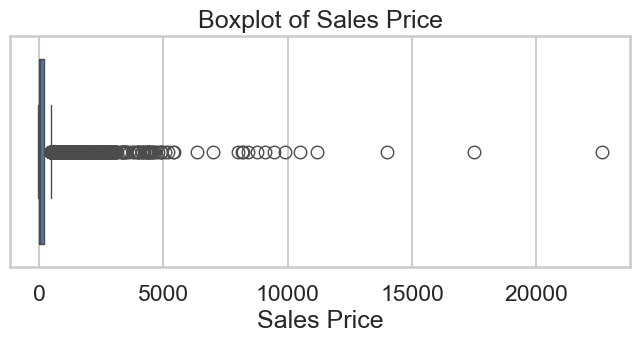

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (8,3))
sns.boxplot(x = store_sale['Sales Price'])
plt.title(f'Boxplot of Sales Price')
plt.show()

In [39]:
# Generalized Functions to get the idea of outliers present in our dataset:

def remove_outliers(df , column , factor = 3):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - (factor * IQR)
    upper = Q3 + (factor * IQR)

    print(f'Detecting outliers in {column} using 3* IQR')
    print((f'Lower bound {lower: .3f}, Upper bound {upper: .3f}'))   
    
    Outliers = df[(df[column] < lower) | (df[column] > upper)] # Outliers
    
    print(f'impacted rows: {Outliers.shape[0]}')
    print(f'impacted order Ids: {Outliers['Order ID'].nunique()}')
    
    Cleaned_Df = df[(df[column] >= lower) & (df[column] <= upper)] # Cleaned Df

    return Cleaned_Df

In [40]:
store_sale_copy.shape

(9986, 34)

In [86]:
store_sale_copy = remove_outliers(store_sale_copy , 'Sales Price')

Detecting outliers in Sales Price using 3* IQR
Lower bound -411.928, Upper bound  586.104
impacted rows: 307
impacted order Ids: 296


In [42]:
store_sale_copy.shape

(9318, 34)

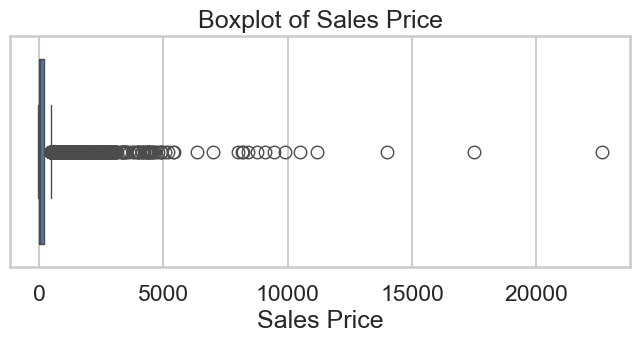

In [85]:
# After removing outlier for Sales Price

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (8,3))
sns.boxplot(x = store_sale['Sales Price'])
plt.title(f'Boxplot of Sales Price')
plt.show()

In [44]:
Customer_Sale= store_sale_copy.groupby('Customer ID')['Total Sales'].sum() # Total Sales per Customer ID 

Customer_Profit = store_sale_copy.groupby('Customer ID')['Total Profit'].sum() # Total Profit per Customer ID
Customer_Sale_Quintile= pd.qcut(Customer_Sale, q = 5, labels = ['1','2','3','4','5']) # Divided per Customer Total Sale into 5 equal parts in ascending order 1<2<3<4<5

Customer_Profit_Quintile = pd.qcut(Customer_Profit, q = 5, labels = ['1','2','3','4','5']) # Similarly Divided per Customer Total Profit into 5 equal parts in ascending order 1<2<3<4<5
cross_tab = pd.crosstab(Customer_Sale_Quintile, Customer_Profit_Quintile,)
cross_tab

Total Profit,1,2,3,4,5
Total Sales,,,,,
1,39,87,32,1,0
2,32,33,63,30,0
3,22,20,32,59,25
4,34,10,19,43,52
5,32,8,12,25,82


`Generated a cross-tabulation table to analyze the relationship between customer sales volume and overall customer profitability`
`The analysis indicates that customers in the fifth quintile representing the highest purchase volume also generated the highest overall profit`

### Sale and profit analysis

`Top 10 most profitable products`

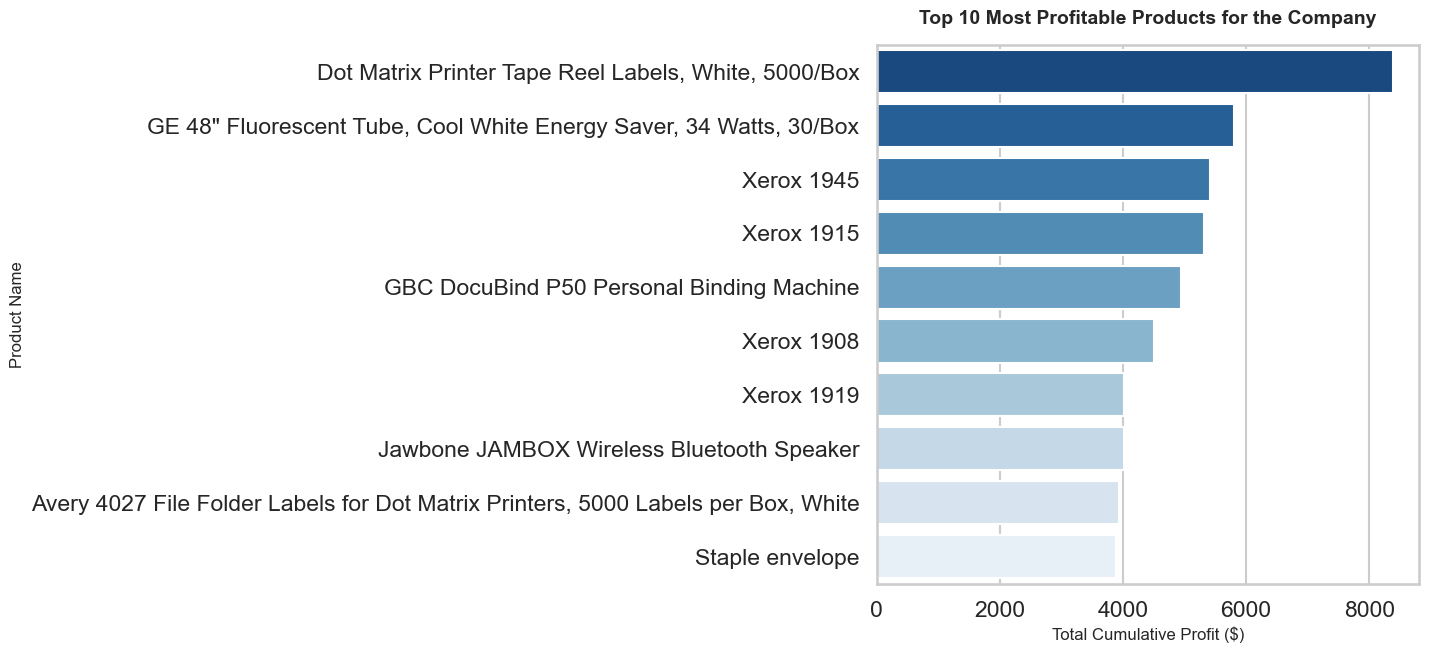

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

Top_10_products=store_sale_copy.groupby('Product Name')['Total Profit'].sum().nlargest(10).reset_index()

sns.set_theme(style="whitegrid", context="talk") # Clean white grid baseline
plt.figure(figsize=(7, 7), dpi=100) 


sns.barplot(
    
    data = Top_10_products,
    x='Total Profit',
    y='Product Name',
    palette='Blues_r'
)


plt.title('Top 10 Most Profitable Products for the Company', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Cumulative Profit ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

# Display the graph

plt.savefig("Top 10 Most Profitable Products for the Company.png", dpi=100, bbox_inches="tight")



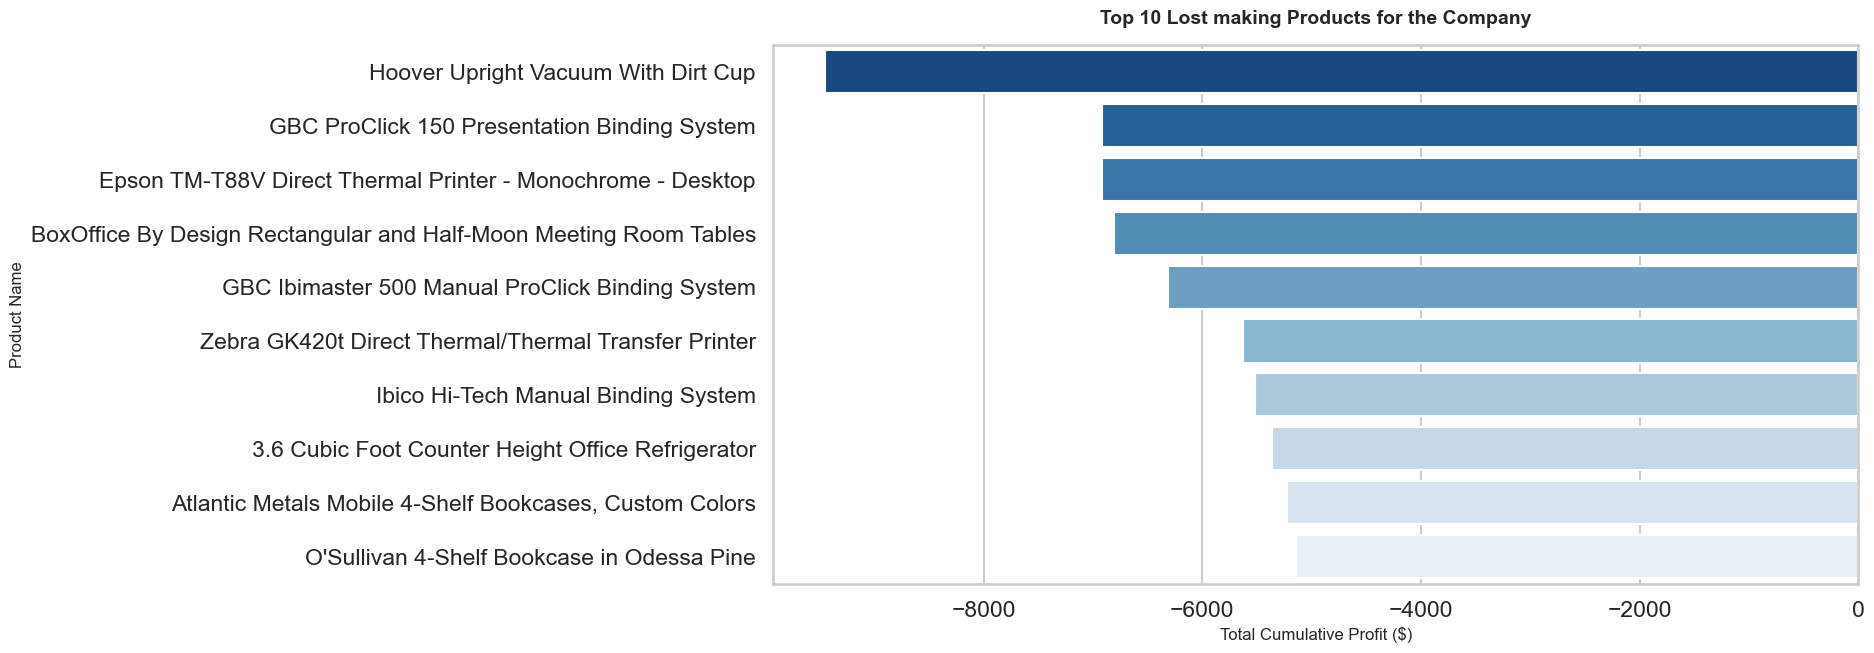

In [81]:
#Top 10 Lost making products

Top_10_products=store_sale_copy.groupby('Product Name')['Total Profit'].sum().nsmallest(10).reset_index()
sns.set_theme(style="whitegrid", context="talk") 
plt.figure(figsize=(14, 7), dpi=100) 

sns.barplot(
    
    data = Top_10_products,
    x='Total Profit',
    y='Product Name',
    palette='Blues_r'
)

plt.title('Top 10 Lost making Products for the Company', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Cumulative Profit ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

plt.show()

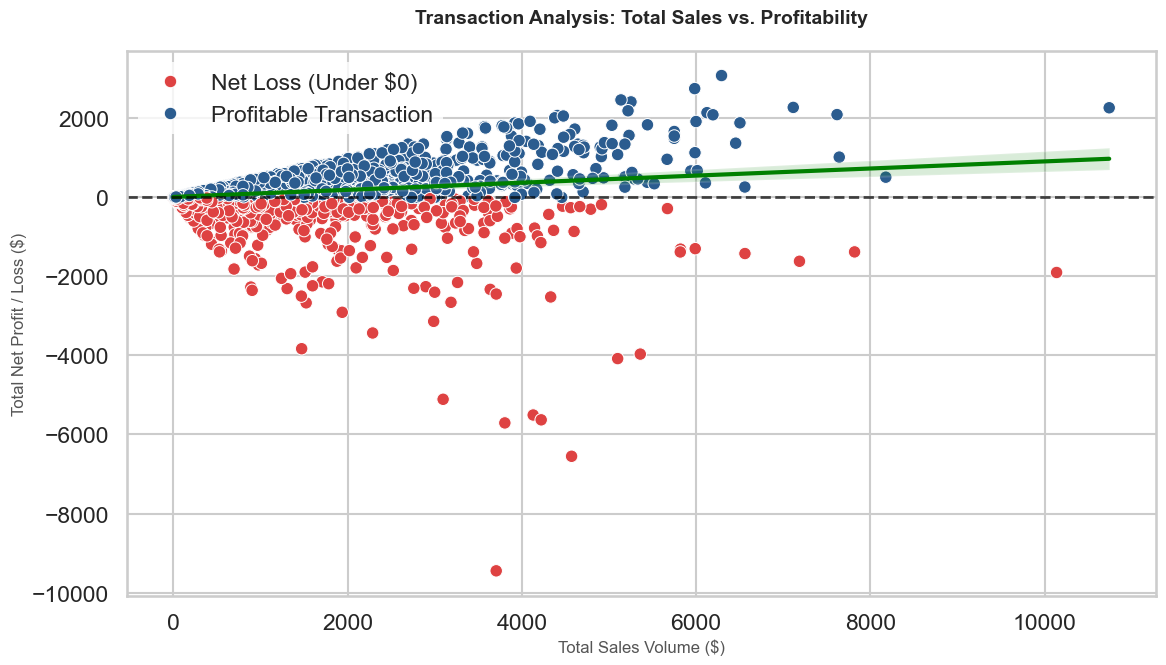

In [83]:
# Set a clean, professional white grid theme

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7), dpi=100)

# Create a dynamic color column just for this chart (True if profitable, False if a loss)

store_sale_copy['Is Profitable'] = store_sale_copy['Total Profit'] >= 0

# Scatter plot
ax = sns.scatterplot(
    data=store_sale_copy,
    x='Total Sales',          
    y='Total Profit',         
    hue='Is Profitable',      
    palette={True: '#2b5c8f', False: '#de4242'}, 
)

# Calculated regression line onto the existing scatter plot
sns.regplot(
    data=store_sale_copy,
    x='Total Sales',
    y='Total Profit',
    scatter=False,            
    ax=ax, # Draw it on the exact same axis grid
    line_kws = {
        'color': 'green',   
        'linewidth': 3,   
        'linestyle': '-'
    }
)
# clean, bold horizontal line at exactly $0 Profit to separate Profit and Loss making transactions
plt.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)

plt.title('Transaction Analysis: Total Sales vs. Profitability', fontsize=14, fontweight='bold', pad=20, loc='center')
plt.xlabel('Total Sales Volume ($)', fontsize=12, color='#555555')
plt.ylabel('Total Net Profit / Loss ($)', fontsize=12, color='#555555')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['Net Loss (Under $0)', 'Profitable Transaction'], loc='upper left', frameon=True, edgecolor='none')

plt.tight_layout()

plt.savefig("Total Sales vs. Profits.png", dpi=100, bbox_inches="tight")



`The plot indicates a clear breakeven threshold at a sales volume of approximately $6,000. Below this mark, net profits and losses generally offset one another, resulting in a neutral overall financial impact. Conversely, when sales volume exceeds $6,000, baseline profitability remains stable, but the risk of major losses is eliminated, with total profits occasionally surpassing $2,000.`

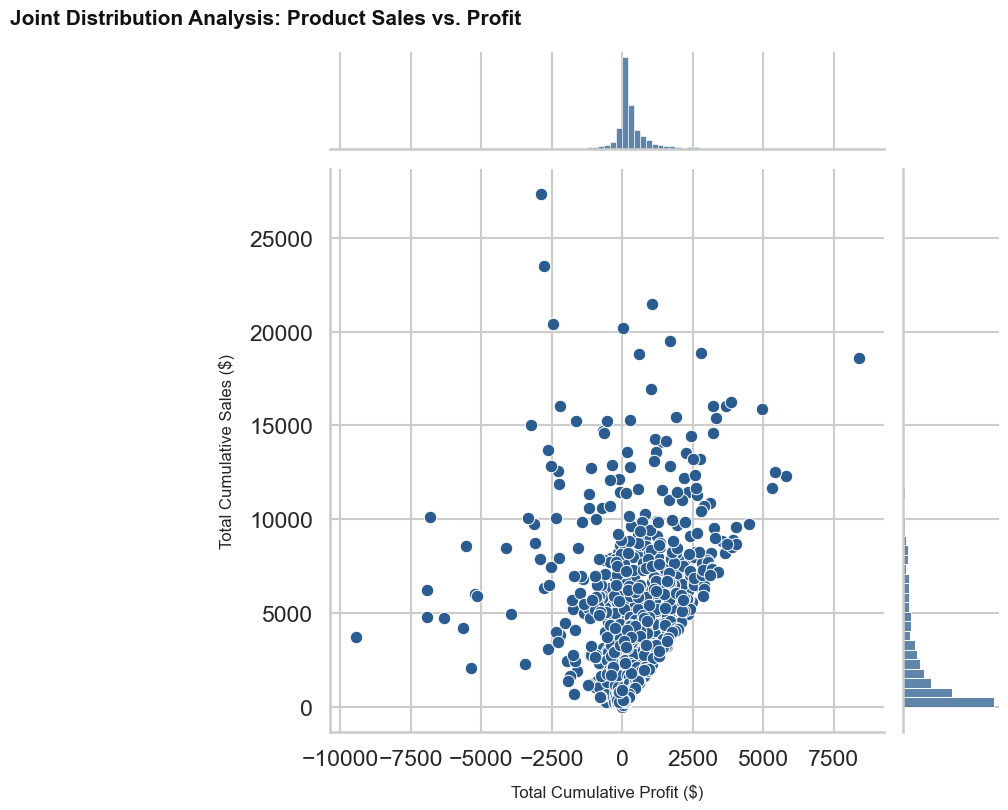

In [48]:
Sale_Profit_products=store_sale_copy.groupby('Product Name')[['Total Profit','Total Sales']].sum()

g = sns.jointplot(
    data=Sale_Profit_products,
    x='Total Profit',
    y='Total Sales',
    color='#2b5c8f',         
    height=8, # Squares up the dimensions cleanly
    ratio=5,  # Balances the size between central plot and outer histograms
)
g.set_axis_labels('Total Cumulative Profit ($)', 'Total Cumulative Sales ($)', fontsize=12, labelpad=10)

g.fig.suptitle('Joint Distribution Analysis: Product Sales vs. Profit', 
               fontsize=15, fontweight='bold', y=1.02, x=0.05,color='#111111')

plt.show()

`The chart shows that risk and profit change completely depending on the sales volume. Most losses happen below $15,000, except for three large sale volume between $20,000 and $25,000 that lost around $2,500 each. Within this lower-volume segment, a significant number of transactions operate at a net loss, including several critical outliers where losses exceeded -$5,000 despite low revenue generation. At the same time, three small transactions were highly profitable, making over $5,000 despite their low sales volume`

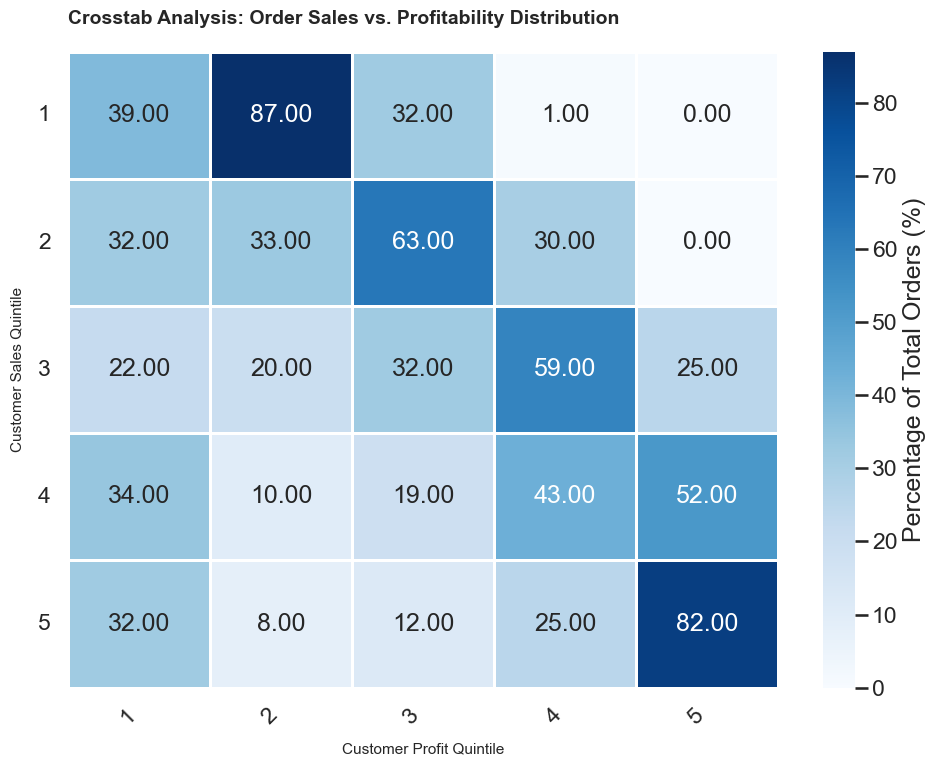

In [49]:
plt.figure(figsize=(10, 8), dpi=100)
ax = sns.heatmap(
    cross_tab,
    annot=True,              # Prints the percentage numbers inside each cell
    fmt='.2f',               
    cmap='Blues',            
    cbar_kws={'label': 'Percentage of Total Orders (%)'}, # Labels bar scale
    linewidths=1,            # Adds a crisp white border between squares
    linecolor='white'
)

plt.title('Crosstab Analysis: Order Sales vs. Profitability Distribution', fontsize=14, fontweight='bold', pad=20, loc='left')
plt.xlabel('Customer Profit Quintile', fontsize=11, fontweight='medium', labelpad=10)
plt.ylabel('Customer Sales Quintile', fontsize=11, fontweight='medium', labelpad=10)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


`The heatmap reveals a strong diagonal correlation, indicating that profit tier generally scales with sales volume. The most valuable segment is at the bottom-right (82% at Quintile 5/5), proving that our highest-volume buyers are also our most profitable. Conversely, the 87% concentration at the top-left (Quintile 1/2) highlights a massive operational bottleneck: a high volume of low-value orders generating minimal profit.`

In [50]:
# Analyze different product categories among different customer segements

category_segment_pivot = pd.pivot_table(
    data=store_sale_copy,                               
    values=['Total Sales', 'Total Profit'],        
    index=['Segment','Category'],                 
    aggfunc='sum',
    sort = True
).sort_values(by = 'Total Profit', ascending = False)

# Apply a professional color gradient to highlight extremes Values

category_segment_pivot.style.background_gradient(
    subset=['Total Profit'], 
    cmap='RdYlGn' # Red (Low/Loss) to Yellow (Mid) to Green (High Profit)
).format('${:,.2f}') # Passing a single string format applies it to all columns globally


,,Total Profit,Total Sales
Segment,Category,,
Consumer,Office Supplies,"$160,980.17","$957,303.61"
Corporate,Office Supplies,"$107,931.65","$611,054.20"
Consumer,Technology,"$106,691.79","$680,871.73"
Home Office,Office Supplies,"$76,699.12","$362,330.64"
Corporate,Technology,"$50,733.18","$373,297.77"
Home Office,Technology,"$32,884.46","$255,154.00"
Consumer,Furniture,"$3,874.13","$759,850.28"
Home Office,Furniture,$-526.79,"$243,626.86"
Corporate,Furniture,"$-5,942.01","$473,961.88"


`The most profit category and customer segment is Consumer in Office Supplies $160,980.17. Coversly, highest loss making segmemt and cateogory is Corporate in Furniture $-5,942.01 `

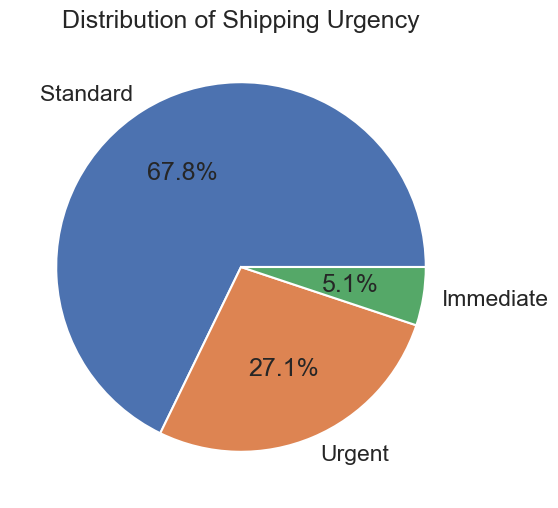

In [51]:
# Distribution of Shipping Urgency

Different_ships =store_sale_copy['Shipping Urgency'].value_counts()
Different_ships.plot.pie(
        autopct='%1.1f%%',   
        figsize=(6, 6),      
        ylabel='' # Hides vertical label
)

plt.title('Distribution of Shipping Urgency')
plt.show()


`The above pie chart shows that around 67.8 % orders shipped after 3 days, 27.1 % order shipped within 3 days and around 5.1% order shipped on same day`

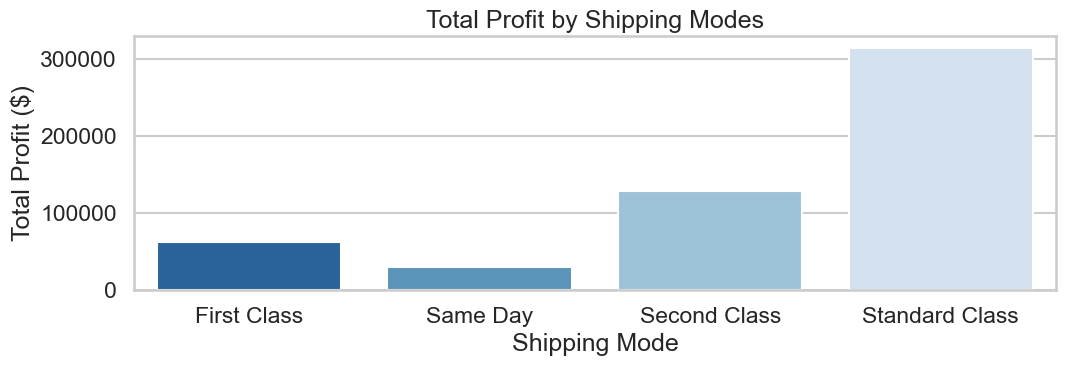

In [52]:
# Compared profitability of different ship modes

grouped_data = store_sale_copy.groupby('Ship Mode')['Total Profit'].sum().reset_index()

plt.figure(figsize=(11, 4), dpi=100)

sns.barplot(data=grouped_data, x='Ship Mode', y='Total Profit', palette='Blues_r')

plt.title('Total Profit by Shipping Modes')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.show()



`The most profitable shipping method is Standard Class, while First Class represents the lowest profit shipping mode`

In [53]:
# Analyze which shipping mode preferable across different regions and impact on Profit & Sale

pd.pivot_table(
    data = store_sale_copy,
    values= ['Order ID', 'Total Sales', 'Total Profit'],
    index= ['Region','Ship Mode'],
    aggfunc= {
        'Order ID': 'count',
        'Total Sales':'mean', 
        'Total Profit': 'mean'},
    
).sort_values(by=['Total Profit','Total Sales'],ascending = False)



Order ID  Total Profit  Total Sales
Region  Ship Mode                                          
South   Second Class         300    113.500448   548.566992
West    Second Class         582    104.377351   556.601051
South   Same Day              78    101.710308   496.057731
        Standard Class       909     86.139926   508.045923
West    Standard Class      1748     76.343842   539.628394
South   First Class          218     73.718294   474.672927
West    Same Day             169     69.073184   472.534817
East    Standard Class      1561     67.002392   486.125516
        Second Class         494     51.608369   510.290508
        Same Day             137     51.234860   489.229715
West    First Class          483     49.153311   512.850753
East    First Class          454     48.987006   462.978787
Central Same Day             115     28.121939   430.398748
        Second Class         435     19.470751   539.062512
        First Class          282      0.472304   465.167915
        Standard Class      1353     -2.122541   487.462896

`Shipping preferences and performance vary significantly by geography. Second Class is the most preferred and profitable shipping mode in both the South and West regions. Conversely, Standard Class is favored in the East region, yielding strong profit numbers, while Same Day delivery is the top choice in the Central region`

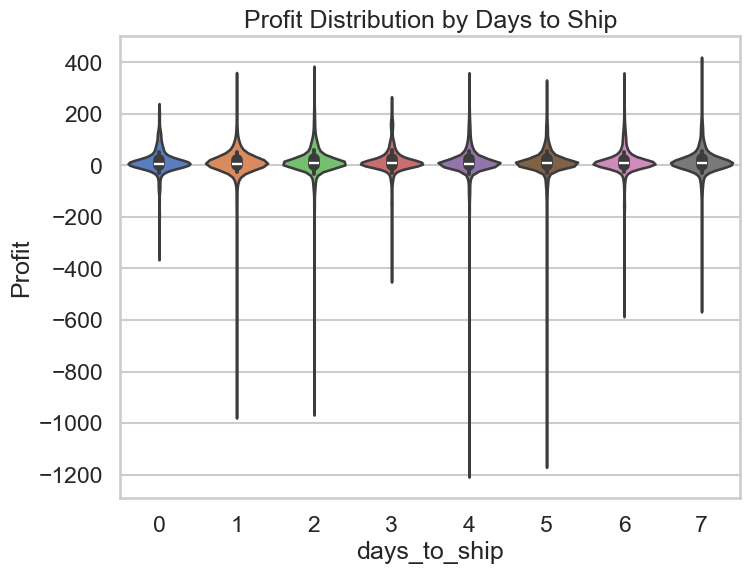

In [54]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=store_sale_copy, x='days_to_ship', y='Profit', palette='muted')

plt.title('Profit Distribution by Days to Ship')
plt.show()


`The violin plot reveals that orders shipped on the 4th and 5th days incur the highest losses. Similarly, orders shipped on the 1st and 2nd days experience significant losses compared to those processed on the same day, 3rd, 6th, or 7th day. Conversely, the highest overall profitability is concentrated among orders shipped on the 7th day`

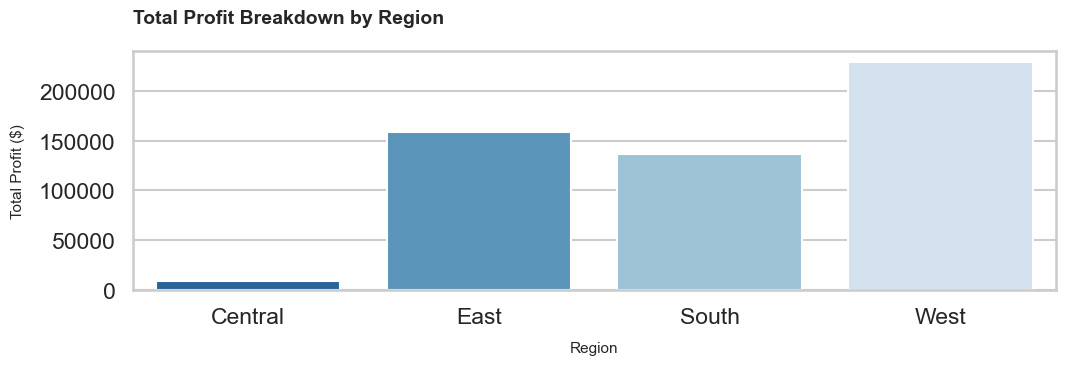

In [79]:
# Region Sales and profitability 

import matplotlib.pyplot as plt
import seaborn as sns

sale_profit_by_region = store_sale_copy.groupby('Region')[['Total Sales', 'Total Profit']].sum().reset_index()

plt.figure(figsize=(11, 4), dpi=100)

# Create a clean bar plot from your grouped data
sns.barplot(data=sale_profit_by_region, x='Region', y='Total Profit', palette='Blues_r')


plt.title('Total Profit Breakdown by Region', fontsize=14, fontweight='bold', pad=20, loc='left')
plt.xlabel('Region', fontsize=11, labelpad=10)
plt.ylabel('Total Profit ($)', fontsize=11, labelpad=10)

plt.tight_layout()

plt.savefig("Profits by Region.png", dpi=100, bbox_inches="tight")


In [76]:
# State wise profits

State_wise_profits=pd.pivot_table(
    data = store_sale_copy,
    values= 'Total Profit',
    index= 'State', 
    aggfunc = 'sum'
    
).sort_values(by = ['Total Profit'],ascending = False)

State_wise_profits.style.background_gradient(
    subset=['Total Profit'], 
    cmap='RdYlGn' # Red (Low/Loss) to Yellow (Mid) to Green (High Profit)
).format('${:,.2f}') # Passing a single string format applies it to all columns globally



,Total Profit
State,
California,"$201,908.82"
New York,"$123,927.81"
Washington,"$44,275.17"
Michigan,"$40,501.36"
Georgia,"$31,211.76"
Virginia,"$30,314.99"
Kentucky,"$22,157.77"
Wisconsin,"$21,110.59"
Indiana,"$20,639.47"


`California is the highest profit making State and Texas is the highest loss making State`

In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
store_sale_copy['encoded_States'] = le.fit_transform(store_sale_copy['State'])
store_sale_copy['encoded_States'].unique()

state_wise_profit_crossTab= pd.crosstab(store_sale_copy['encoded_States'],store_sale_copy['Total Profit'])


`Impact of Discounts on Profits`

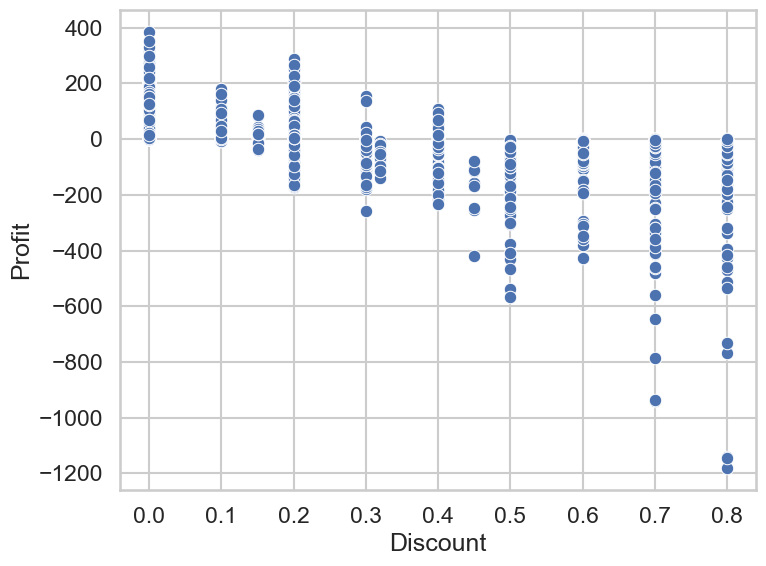

In [58]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data = store_sale_copy,
    x = store_sale_copy['Discount'] ,
    y = store_sale_copy['Profit'] ,
)
plt.tight_layout()


`The scatter plot shows a clear inverse relationship: net losses escalate as discounts increase. Beyond the 50% discount threshold, profitability is entirely eliminated. Conversely, discounts remaining below 50% yield profits, with the highest profitability concentrated at the 0% and 10% discount levels`

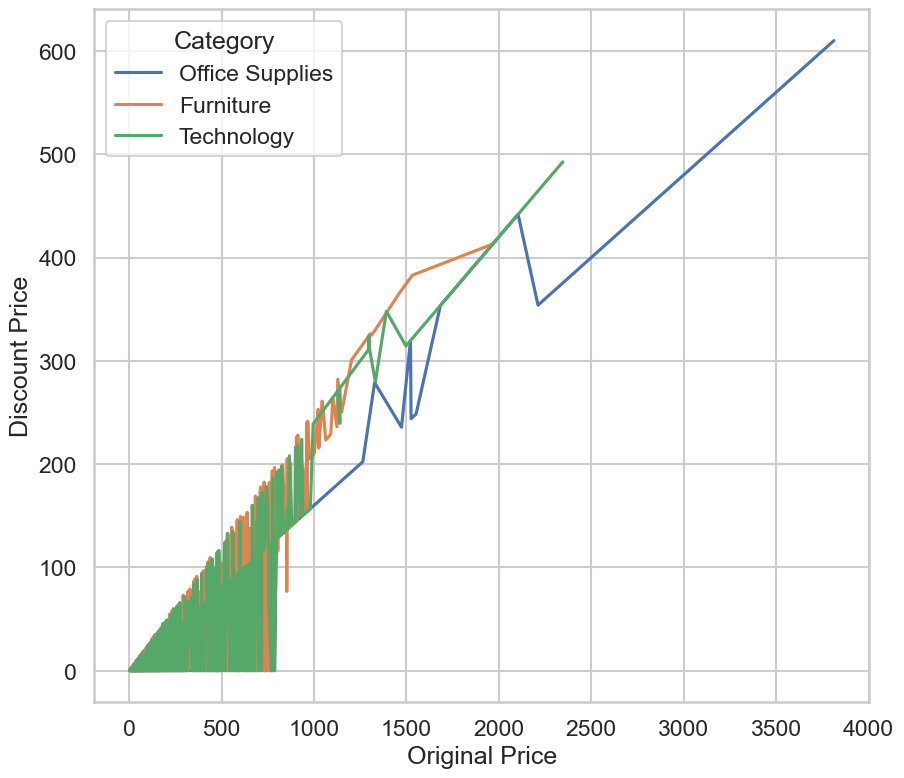

In [59]:
# Original and Discounted price across different product categories
plt.figure(figsize=(10,9))
sns.lineplot(
    data = store_sale_copy,
    x = store_sale_copy['Original Price'],
    y = store_sale_copy['Discount Price'],
    hue = 'Category',
)
plt.savefig("Number of orders accross different months.png", dpi=100, bbox_inches="tight")


`Office Supplies reaches the highest original and discounted price points, followed by Technology, while Furniture reflects the lowest original
price`

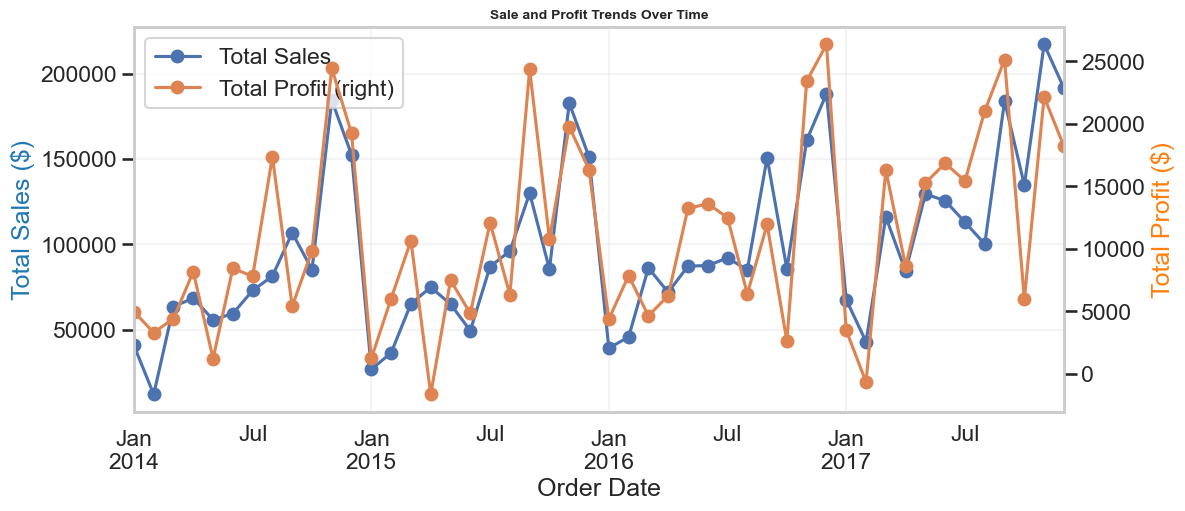

In [71]:
# Sale and Profit Trends Over Time:

Sale_profit_Trend = (store_sale_copy
    .set_index('Order Date')
    .resample('MS')[['Total Sales','Total Profit']]
    .sum())

# Add secondary_y to assign 'Total Profit' to its own right-side axis
ax = Sale_profit_Trend.plot(secondary_y=['Total Profit'], figsize=(12, 5), marker='o')

# Label your axes properly so you can read both scales
ax.set_ylabel('Total Sales ($)', color='tab:blue')
ax.right_ax.set_ylabel('Total Profit ($)', color='tab:orange')

ax.set_title('Sale and Profit Trends Over Time', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.savefig("Sale and profit Trends Over time.png", dpi=100, bbox_inches="tight")


`The above time-series plot indicates that total profits peaked at their highest level near the end of 2016, exceeding $25,000, while the most significant net loss occurred in mid-2015. In terms of revenue, total sales peaked above $200,000 in late 2017, contrasting sharply with the historical low of approximately $12,000 recorded in early 2014. Additionally, in Q3 2015 marked a strong seasonal profit spike, briefly rallying to roughly $24,000`

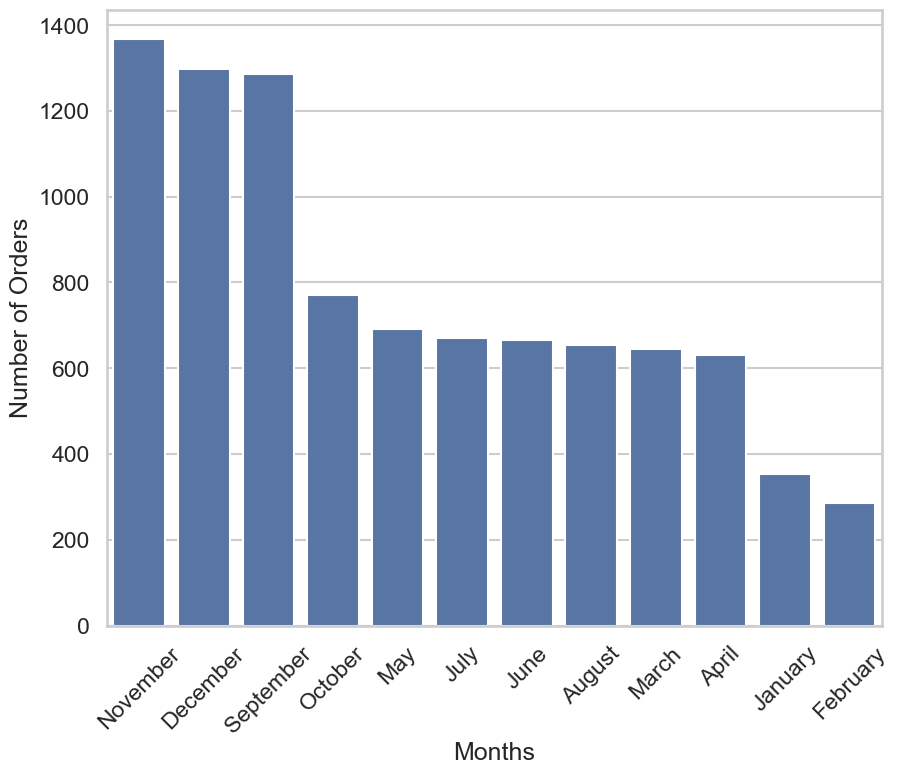

In [70]:
plt.figure(figsize=(10,8))
Order_frequency_month = store_sale_copy['Order Date'].dt.month_name().value_counts()
sns.barplot(Order_frequency_month)
plt.xlabel('Months')
plt.ylabel('Number of Orders')
plt.xticks(rotation = 45)

plt.savefig("Number of orders accross different months.png", dpi=100, bbox_inches="tight")


`The chart indicates a clear seasonal trend --> September, November, and December are consistently our most profitable months of the year, while January and February represent the lowest-earning periods`

## Yearly Growth in Sales and Profits

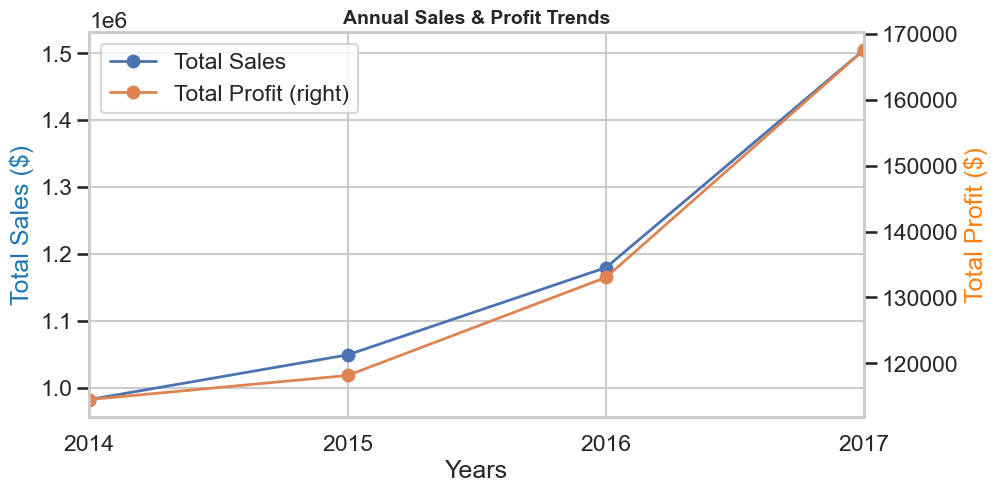

In [66]:

Year_sale_Trend = (store_sale_copy
    .set_index('Order Date')
    .resample('YS')[['Total Sales', 'Total Profit']] # Resample using 'YS' (Year Start) for clean annual aggregation

    .sum()) 

# Plot with a secondary axis for Profit so both trends are clear
ax = Year_sale_Trend.plot(secondary_y=['Total Profit'], figsize=(10, 5), marker='o', linewidth=2)

ax.set_xlabel('Years')
ax.set_ylabel('Total Sales ($)', color='tab:blue')
ax.right_ax.set_ylabel('Total Profit ($)', color='tab:orange')
ax.set_title('Annual Sales & Profit Trends', fontsize=14, fontweight='bold')


plt.savefig("Annual Sales & Profit Trends.png", dpi=300, bbox_inches="tight")

plt.show()

`The annual growth chart demonstrates an upward trajectory, with 2014 serving as the historical baseline for both sale and profit. Steady growth was maintained through 2015 and 2016, followed by a substantial acceleration in 2017. By the close of 2017, annual sales surged past $1.5 million, aligning with a peak net profit of approximately $170,000`